In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

LOAD DATASET


In [4]:
df = pd.read_csv(r"C:\Users\gunjan kumar\Projects\HR Analytics & Employee Attrition Prediction\WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [8]:
print(df)

      Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
...   ...       ...                ...        ...                     ...   
1465   36        No  Travel_Frequently        884  Research & Development   
1466   39        No      Travel_Rarely        613  Research & Development   
1467   27        No      Travel_Rarely        155  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education EducationField  EmployeeCount  \
0       

In [9]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
print(f"Shape: {df.shape}")

Shape: (1470, 35)


In [10]:
print(df["Attrition"].value_counts(normalize=True).mul(100).round(1))

Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64


Binary target




In [11]:
df["Attrition_num"] = (df["Attrition"] == "Yes").astype(int)

Drop zero-variance columns

In [12]:
df.drop(columns=["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"],
        inplace=True, errors="ignore")

1. Overall attrition rate (KPI card style)

   

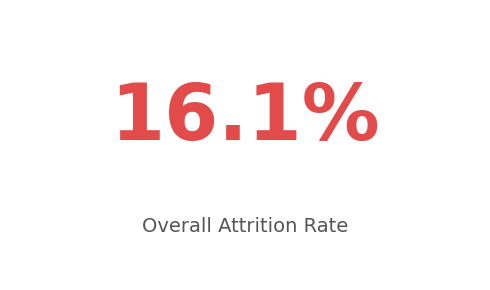

KPI card saved


In [23]:
# Create output folder
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Calculate rate
overall_rate = df["Attrition_num"].mean() * 100

# Plot KPI
fig, ax = plt.subplots(figsize=(5, 3))
ax.text(0.5, 0.6, f"{overall_rate:.1f}%", ha="center", va="center",
        fontsize=56, fontweight="bold", color="#E24B4A", transform=ax.transAxes)

ax.text(0.5, 0.2, "Overall Attrition Rate", ha="center", va="center",
        fontsize=14, color="#555", transform=ax.transAxes)

ax.axis("off")
fig.tight_layout()

# Save image
fig.savefig(f"{OUTPUT_DIR}/01_kpi_overall_rate.png", dpi=150, bbox_inches="tight")
# Show chart
plt.show()

plt.close()

print("KPI card saved")

# ── 2. Attrition by Department (the 34% Sales finding


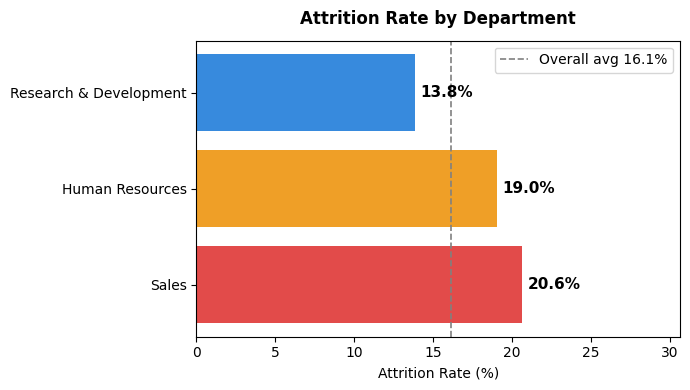

✓ Department chart saved


In [22]:
dept_rate = (df.groupby("Department")["Attrition_num"]
               .mean()
               .mul(100)
               .reset_index()
               .rename(columns={"Attrition_num": "AttritionRate"})
               .sort_values("AttritionRate", ascending=False))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(dept_rate["Department"], dept_rate["AttritionRate"],
               color=["#E24B4A", "#EF9F27", "#378ADD"])
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=11, fontweight="bold")
ax.set_xlabel("Attrition Rate (%)")
ax.set_title("Attrition Rate by Department", fontweight="bold", pad=12)
ax.set_xlim(0, dept_rate["AttritionRate"].max() + 10)
ax.axvline(overall_rate, color="gray", linestyle="--", lw=1.2, label=f"Overall avg {overall_rate:.1f}%")
ax.legend()
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/02_attrition_by_department.png", dpi=150, bbox_inches="tight")
# Show chart
plt.show()
plt.close()
print("✓ Department chart saved")

# ── 3. Attrition by Tenure Band

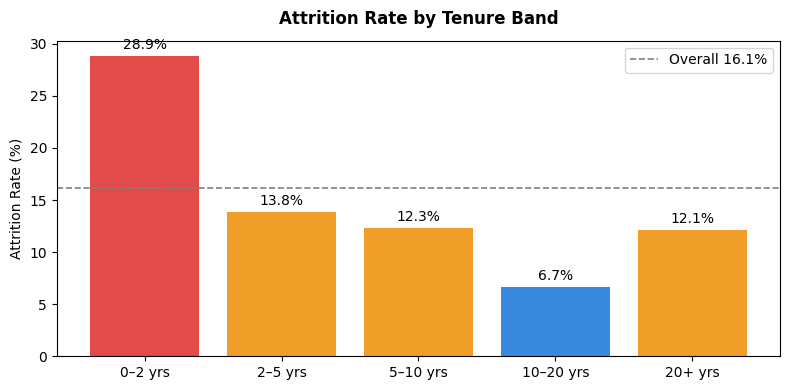

 Tenure chart saved


In [21]:
bins = [0, 2, 5, 10, 20, 40]
labels = ["0–2 yrs", "2–5 yrs", "5–10 yrs", "10–20 yrs", "20+ yrs"]
df["TenureBand"] = pd.cut(df["YearsAtCompany"], bins=bins, labels=labels, right=True)

tenure_rate = (df.groupby("TenureBand", observed=True)["Attrition_num"]
                 .mean()
                 .mul(100)
                 .reset_index()
                 .rename(columns={"Attrition_num": "AttritionRate"}))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#E24B4A" if v > 20 else "#EF9F27" if v > 12 else "#378ADD"
          for v in tenure_rate["AttritionRate"]]
bars = ax.bar(tenure_rate["TenureBand"].astype(str), tenure_rate["AttritionRate"], color=colors)
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=10)
ax.set_ylabel("Attrition Rate (%)")
ax.set_title("Attrition Rate by Tenure Band", fontweight="bold", pad=12)
ax.axhline(overall_rate, color="gray", linestyle="--", lw=1.2, label=f"Overall {overall_rate:.1f}%")
ax.legend()
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/03_attrition_by_tenure.png", dpi=150, bbox_inches="tight")
# Show chart
plt.show()
plt.close()
print(" Tenure chart saved")

# ── 4. Monthly Income Distribution by Attrition

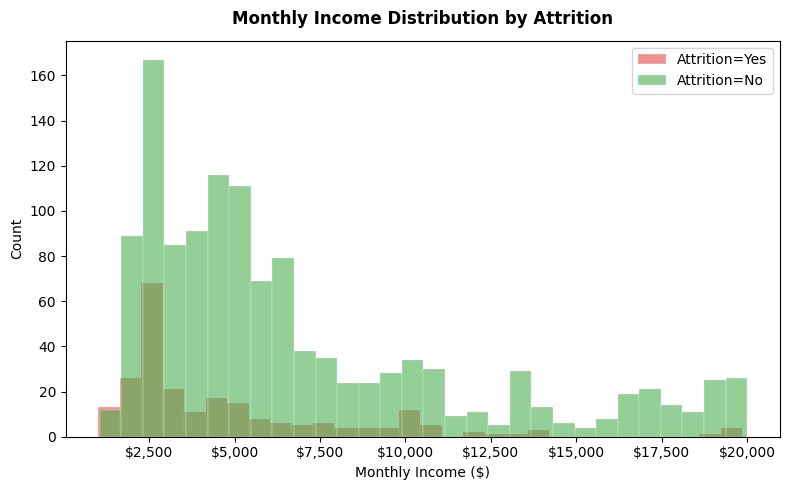

 Income distribution saved


In [20]:
PALETTE = {
    "Yes": "#E24B4A",
    "No": "#4CAF50"
}

fig, ax = plt.subplots(figsize=(8, 5))
for label, color in PALETTE.items():
    subset = df[df["Attrition"] == label]["MonthlyIncome"]
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=f"Attrition={label}",
            edgecolor="white", linewidth=0.3)
ax.set_xlabel("Monthly Income ($)")
ax.set_ylabel("Count")
ax.set_title("Monthly Income Distribution by Attrition", fontweight="bold", pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/04_income_distribution.png", dpi=150, bbox_inches="tight")
# Show chart
plt.show()
plt.close()
print(" Income distribution saved")

# ── 5. Overtime vs Attrition

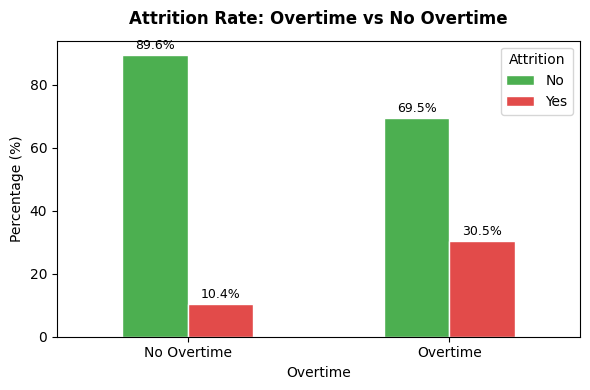

 Overtime chart saved


In [24]:
ot_cross = pd.crosstab(df["OverTime"], df["Attrition"], normalize="index").mul(100)
fig, ax = plt.subplots(figsize=(6, 4))
ot_cross.plot(kind="bar", ax=ax, color=[PALETTE["No"], PALETTE["Yes"]],
              edgecolor="white", width=0.5)
ax.set_xlabel("Overtime")
ax.set_ylabel("Percentage (%)")
ax.set_title("Attrition Rate: Overtime vs No Overtime", fontweight="bold", pad=12)
ax.set_xticklabels(["No Overtime", "Overtime"], rotation=0)
ax.legend(title="Attrition", labels=["No", "Yes"])
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=2, fontsize=9)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/05_overtime_attrition.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(" Overtime chart saved")

6. Correlation Heatmap (numeric cols vs Attrition_num)

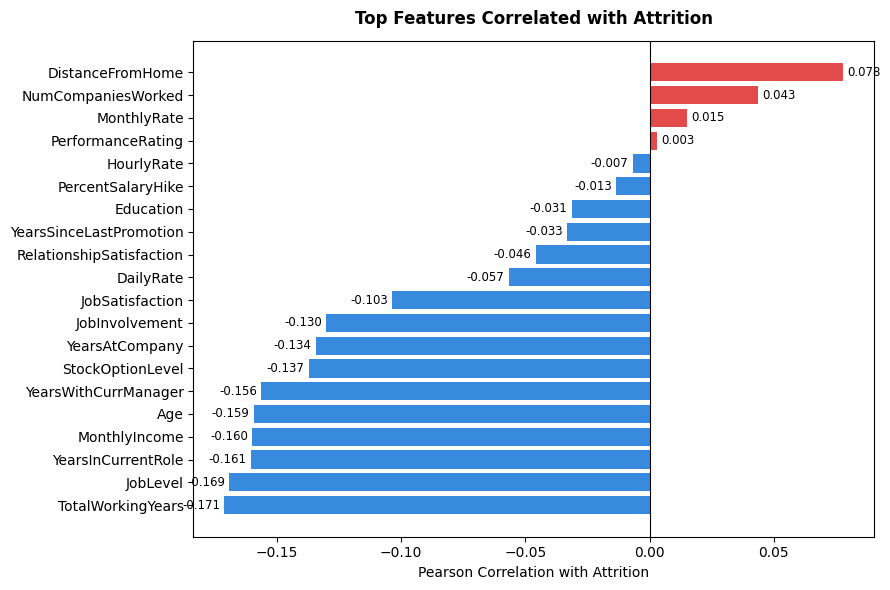

 Correlation chart saved


In [25]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_with_attrition = (df[numeric_cols]
                       .corr()["Attrition_num"]
                       .drop("Attrition_num")
                       .sort_values()
                       .reset_index())
corr_with_attrition.columns = ["Feature", "Correlation"]

# Top 10 positive + top 10 negative
top_corr = pd.concat([
    corr_with_attrition.head(10),
    corr_with_attrition.tail(10)
]).drop_duplicates()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#E24B4A" if v > 0 else "#378ADD" for v in top_corr["Correlation"]]
bars = ax.barh(top_corr["Feature"], top_corr["Correlation"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation with Attrition")
ax.set_title("Top Features Correlated with Attrition", fontweight="bold", pad=12)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8.5)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/06_correlation_with_attrition.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(" Correlation chart saved")

# ── 7. Job Satisfaction vs Attrition (Stacked bar)

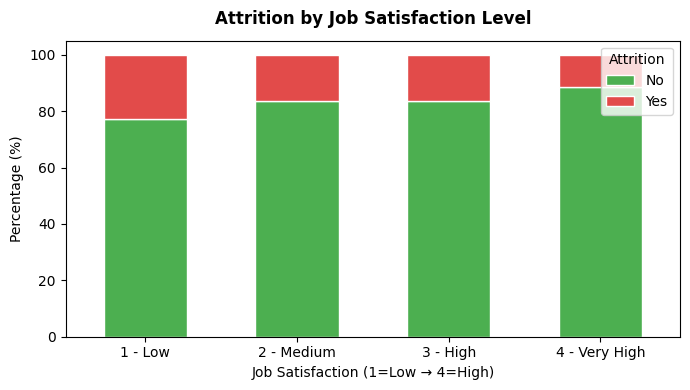

 Job satisfaction chart saved


In [26]:
sat_cross = pd.crosstab(df["JobSatisfaction"], df["Attrition"], normalize="index").mul(100)
fig, ax = plt.subplots(figsize=(7, 4))
sat_cross.plot(kind="bar", stacked=True, ax=ax,
               color=[PALETTE["No"], PALETTE["Yes"]], edgecolor="white", width=0.55)
ax.set_xlabel("Job Satisfaction (1=Low → 4=High)")
ax.set_ylabel("Percentage (%)")
ax.set_title("Attrition by Job Satisfaction Level", fontweight="bold", pad=12)
ax.set_xticklabels(["1 - Low", "2 - Medium", "3 - High", "4 - Very High"], rotation=0)
ax.legend(title="Attrition", labels=["No", "Yes"], loc="upper right")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/07_satisfaction_attrition.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(" Job satisfaction chart saved")

# ── 8. Attrition by Job Role

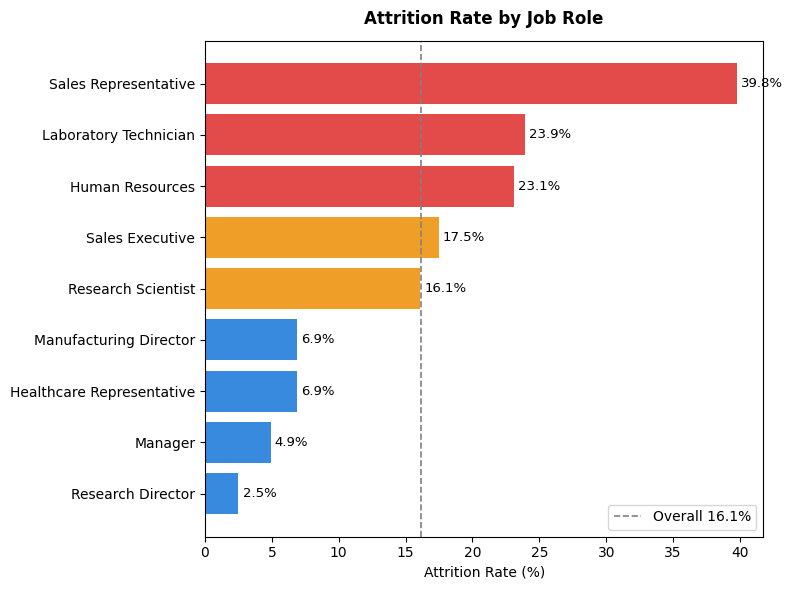

Job role chart saved


In [27]:
role_rate = (df.groupby("JobRole")["Attrition_num"]
               .mean()
               .mul(100)
               .reset_index()
               .rename(columns={"Attrition_num": "AttritionRate"})
               .sort_values("AttritionRate", ascending=True))

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#E24B4A" if v > 20 else "#EF9F27" if v > 12 else "#378ADD"
          for v in role_rate["AttritionRate"]]
bars = ax.barh(role_rate["JobRole"], role_rate["AttritionRate"], color=colors)
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9.5)
ax.axvline(overall_rate, color="gray", linestyle="--", lw=1.2, label=f"Overall {overall_rate:.1f}%")
ax.set_xlabel("Attrition Rate (%)")
ax.set_title("Attrition Rate by Job Role", fontweight="bold", pad=12)
ax.legend()
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/08_attrition_by_jobrole.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("Job role chart saved")

# ── 9. Age Distribution by Attrition

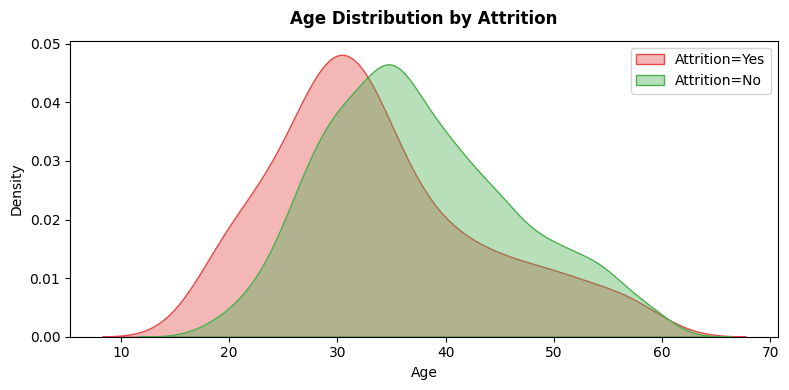

 Age distribution saved


In [28]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, color in PALETTE.items():
    subset = df[df["Attrition"] == label]["Age"]
    sns.kdeplot(subset, ax=ax, color=color, fill=True, alpha=0.4, label=f"Attrition={label}")
ax.set_xlabel("Age")
ax.set_ylabel("Density")
ax.set_title("Age Distribution by Attrition", fontweight="bold", pad=12)
ax.legend()
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/09_age_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(" Age distribution saved")

In [29]:
# ── 10. Save cleaned processed file for ML

In [36]:
path = r"C:\Users\gunjan kumar\Projects\HR Analytics & Employee Attrition Prediction\WA_Fn-UseC_-HR-Employee-Attrition.csv"

df.to_csv(path, index=False)

print(f"\nProcessed dataset saved: {path}")
print(f"\nAll charts saved in: {OUTPUT_DIR}/")

print("01_kpi_overall_rate.png")
print("02_attrition_by_department.png")
print("03_attrition_by_tenure.png")
print("04_income_distribution.png")
print("05_overtime_attrition.png")
print("06_correlation_with_attrition.png")
print("07_satisfaction_attrition.png")
print("08_attrition_by_jobrole.png")
print("09_age_distribution.png")


Processed dataset saved: C:\Users\gunjan kumar\Projects\HR Analytics & Employee Attrition Prediction\WA_Fn-UseC_-HR-Employee-Attrition.csv

All charts saved in: output/
01_kpi_overall_rate.png
02_attrition_by_department.png
03_attrition_by_tenure.png
04_income_distribution.png
05_overtime_attrition.png
06_correlation_with_attrition.png
07_satisfaction_attrition.png
08_attrition_by_jobrole.png
09_age_distribution.png


In [38]:
pip install LogisticRegression

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

In [41]:
OUTPUT_DIR = "outputs/ml"
os.makedirs(OUTPUT_DIR, exist_ok=True)
sns.set_theme(style="whitegrid", font_scale=1.1)

In [42]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != "Attrition"]   # keep target as-is

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [43]:
y = (df["Attrition"] == "Yes").astype(int)
X = df.drop(columns=["Attrition", "Attrition_num"], errors="ignore")

print(f"Features : {X.shape[1]}")
print(f"Samples  : {X.shape[0]}")
print(f"Attrition prevalence: {y.mean()*100:.1f}%")

Features : 31
Samples  : 1470
Attrition prevalence: 16.1%


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

In [45]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE — Train size: {X_train_sm.shape[0]}  "
      f"(Attrition: {y_train_sm.mean()*100:.1f}%)")


After SMOTE — Train size: 1972  (Attrition: 50.0%)


In [46]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)


In [47]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr.fit(X_train_sc, y_train_sm)

lr_preds  = lr.predict(X_test_sc)
lr_proba  = lr.predict_proba(X_test_sc)[:, 1]
lr_acc    = (lr_preds == y_test).mean()
lr_auc    = roc_auc_score(y_test, lr_proba)

print("\n── Logistic Regression ──")
print(f"Accuracy : {lr_acc*100:.1f}%")
print(f"ROC-AUC  : {lr_auc:.3f}")
print(classification_report(y_test, lr_preds, target_names=["Stay", "Leave"]))



── Logistic Regression ──
Accuracy : 79.6%
ROC-AUC  : 0.711
              precision    recall  f1-score   support

        Stay       0.90      0.85      0.88       247
       Leave       0.39      0.51      0.44        47

    accuracy                           0.80       294
   macro avg       0.65      0.68      0.66       294
weighted avg       0.82      0.80      0.81       294



In [48]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)

rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_acc   = (rf_preds == y_test).mean()
rf_auc   = roc_auc_score(y_test, rf_proba)

print("\n── Random Forest ──")
print(f"Accuracy : {rf_acc*100:.1f}%")
print(f"ROC-AUC  : {rf_auc:.3f}")
print(classification_report(y_test, rf_preds, target_names=["Stay", "Leave"]))


── Random Forest ──
Accuracy : 79.6%
ROC-AUC  : 0.734
              precision    recall  f1-score   support

        Stay       0.88      0.88      0.88       247
       Leave       0.36      0.36      0.36        47

    accuracy                           0.80       294
   macro avg       0.62      0.62      0.62       294
weighted avg       0.80      0.80      0.80       294



In [49]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring="roc_auc")
print(f"\nCross-Val ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")



Cross-Val ROC-AUC: 0.806 ± 0.029


In [51]:
import joblib
joblib.dump(rf, f"{OUTPUT_DIR}/model_random_forest.pkl")
joblib.dump(scaler, f"{OUTPUT_DIR}/scaler.pkl")
print(f"\n✓ Model saved → {OUTPUT_DIR}/model_random_forest.pkl")


✓ Model saved → outputs/ml/model_random_forest.pkl


In [54]:
df_orig = pd.read_csv(r"C:\Users\gunjan kumar\Projects\HR Analytics & Employee Attrition Prediction\WA_Fn-UseC_-HR-Employee-Attrition.csv")
X_all = df.drop(columns=["Attrition", "Attrition_num"], errors="ignore")
df_orig["AttritionRiskScore"] = rf.predict_proba(X_all)[:, 1].round(4)
df_orig["RiskTier"] = pd.cut(
    df_orig["AttritionRiskScore"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Low", "Medium", "High"]
)
df_orig.to_csv(f"{OUTPUT_DIR}/hr_with_risk_score.csv", index=False)
print(f" Risk scores saved → {OUTPUT_DIR}/hr_with_risk_score.csv")

 Risk scores saved → outputs/ml/hr_with_risk_score.csv


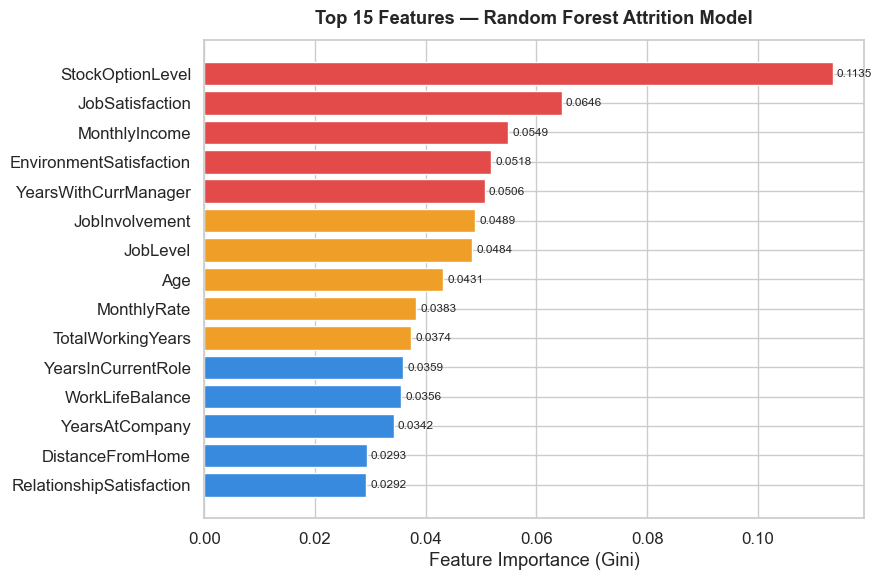

 Feature importance chart saved


In [55]:
feat_imp = (pd.Series(rf.feature_importances_, index=X.columns)
              .sort_values(ascending=False)
              .head(15)
              .reset_index())
feat_imp.columns = ["Feature", "Importance"]

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#E24B4A" if i < 5 else "#EF9F27" if i < 10 else "#378ADD"
          for i in range(len(feat_imp))]
bars = ax.barh(feat_imp["Feature"][::-1], feat_imp["Importance"][::-1], color=colors[::-1])
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title("Top 15 Features — Random Forest Attrition Model", fontweight="bold", pad=12)
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8.5)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(" Feature importance chart saved")

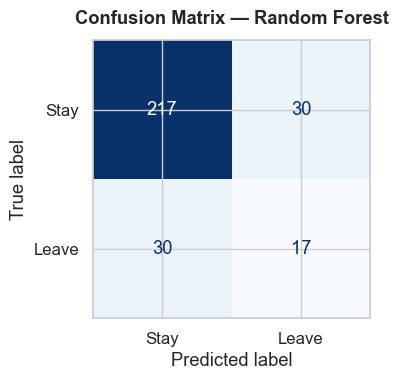

 Confusion matrix saved


In [56]:
cm = confusion_matrix(y_test, rf_preds)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stay", "Leave"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — Random Forest", fontweight="bold", pad=12)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(" Confusion matrix saved")

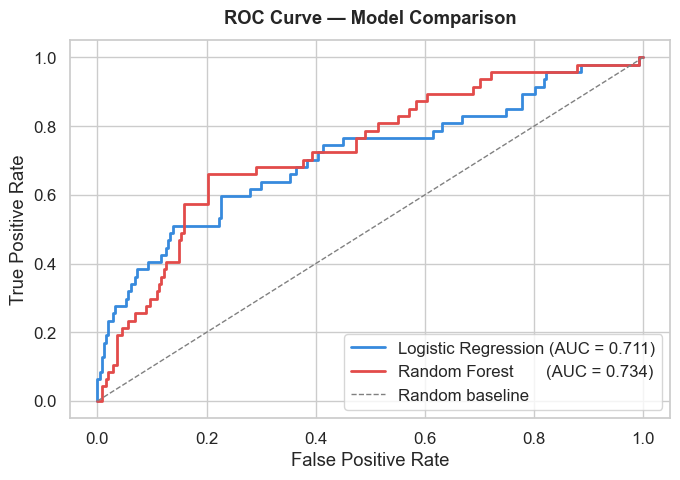

 ROC curve saved


In [57]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(lr_fpr, lr_tpr, color="#378ADD", lw=2,
        label=f"Logistic Regression (AUC = {lr_auc:.3f})")
ax.plot(rf_fpr, rf_tpr, color="#E24B4A", lw=2,
        label=f"Random Forest       (AUC = {rf_auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1, label="Random baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Model Comparison", fontweight="bold", pad=12)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(" ROC curve saved")

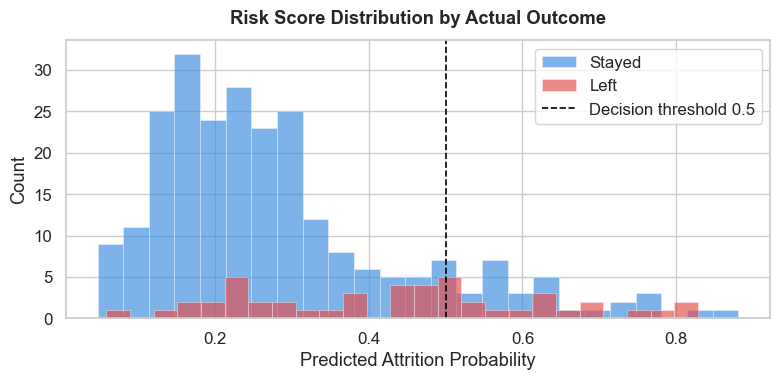

 Risk score distribution saved


In [58]:
fig, ax = plt.subplots(figsize=(8, 4))
for attrition_val, color, label in [(0, "#378ADD", "Stayed"), (1, "#E24B4A", "Left")]:
    mask = y_test == attrition_val
    ax.hist(rf_proba[mask], bins=25, alpha=0.65, color=color,
            label=label, edgecolor="white", linewidth=0.4)
ax.axvline(0.5, color="black", linestyle="--", lw=1.2, label="Decision threshold 0.5")
ax.set_xlabel("Predicted Attrition Probability")
ax.set_ylabel("Count")
ax.set_title("Risk Score Distribution by Actual Outcome", fontweight="bold", pad=12)
ax.legend()
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/risk_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(" Risk score distribution saved")

In [3]:
import pandas as pd
from sqlalchemy import create_engine

# Step 1: Load CSV
df = pd.read_csv(r"C:\Users\gunjan kumar\Projects\HR Analytics & Employee Attrition Prediction\WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Step 2: PostgreSQL connection
username = "postgres"
password = "Gunjan123"
host = "localhost"
port = "5432"
database = "hr_analytics"

engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

# Step 3: Upload to PostgreSQL
df.to_sql("hr_analytics", engine, if_exists="replace", index=False)

print("Data successfully uploaded!")

Data successfully uploaded!
